# 03 — Charge-off rates & vintage cohort curves

**Plain English:** Now we look at *who defaults*. The **charge-off rate** is charged-off loans ÷ total loans in a segment. We break it down by industry, loan-size band, and **vintage** (approval-year cohort).

Then we build **vintage cohort curves**: for each approval-year, the cumulative charge-off rate as the loans age (months since approval). This is the classic credit-risk view of how cohorts season.

**Seasoning caveat:** recent vintages haven't had time to fully default, so their rates understate the eventual total — we flag those.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
pd.set_option('display.max_columns', 40, 'display.width', 200)
from src.config import load_config, TABLES_DIR
CFG = load_config()

In [2]:
from src.data_loader import load_clean
from src.base_table import build_base_table
loans = load_clean(config=CFG)
base = build_base_table(loans, config=CFG)
print(f'{len(base):,} funded loans, vintages {int(base.vintage.min())}-{int(base.vintage.max())}')

[2026-06-12 11:25:25] [INFO    ] [data_loader] Loading 2 SBA input file(s): ['foia-7a-fy2000-fy2009-asof-260331.csv', 'foia-7a-fy2010-fy2019-asof-260331.csv']


[2026-06-12 11:25:28] [INFO    ] [data_loader]   foia-7a-fy2000-fy2009-asof-260331.csv -> 690333 rows


[2026-06-12 11:25:30] [INFO    ] [data_loader]   foia-7a-fy2010-fy2019-asof-260331.csv -> 545751 rows


[2026-06-12 11:25:31] [INFO    ] [data_loader] Combined raw frame: 1236084 rows


[2026-06-12 11:25:34] [INFO    ] [data_loader] Dropped 149065 never-funded loans (['CANCLD', 'COMMIT']); 1087019 funded loans remain


[2026-06-12 11:25:34] [INFO    ] [base_table] Base table built: 1087019 loans, 20 vintages (2000-2019), 132662 defaults


1,087,019 funded loans, vintages 2000-2019


In [3]:
from src import chargeoff as co, vintage
from src.charts import plot_chargeoff_by_vintage, plot_vintage_curves, plot_chargeoff_bar
co_ind = co.chargeoff_by_industry(base)
co_size = co.chargeoff_by_size_band(base)
co_vin = co.chargeoff_by_vintage(base)
curves = vintage.compute_vintage_curves(base, config=CFG)
co_ind.to_csv(TABLES_DIR / '03_chargeoff_by_industry.csv', index=False)
co_size.to_csv(TABLES_DIR / '03_chargeoff_by_size_band.csv', index=False)
co_vin.to_csv(TABLES_DIR / '03_chargeoff_by_vintage.csv', index=False)
curves.reset_index().to_csv(TABLES_DIR / '03_vintage_cohort_curves.csv', index=False)

[2026-06-12 11:25:34] [INFO    ] [vintage] Vintage curves: as-of date 2026-04-01, MOB grid [6, 12, 18, 24, 36, 48, 60, 72, 84, 96, 120]


### Result: charge-off rate by vintage
Watch the 2005–2008 cohorts — loans made into the financial crisis.

In [4]:
co_vin

,vintage,loan_count,defaults,exposure,chargeoff_amount,chargeoff_rate_count,chargeoff_rate_dollar,fully_seasoned
0,2000,37600,1759,8.999369e+09,8.505008e+08,0.0468,0.0945,True
1,2001,37323,2179,8.550460e+09,7.726850e+08,0.0584,0.0904,True
2,2002,45184,3103,1.056788e+10,7.695536e+08,0.0687,0.0728,True
3,2003,59119,5560,9.689071e+09,7.242937e+08,0.0940,0.0748,True
4,2004,71283,8735,1.177058e+10,1.041689e+09,0.1225,0.0885,True
5,2005,84436,14876,1.320815e+10,1.831064e+09,0.1762,0.1386,True
6,2006,86570,21002,1.275156e+10,2.606531e+09,0.2426,0.2044,True
7,2007,88270,25436,1.257850e+10,3.099103e+09,0.2882,0.2464,True
8,2008,61636,14901,1.110268e+10,2.125238e+09,0.2418,0.1914,True
9,2009,36636,4262,8.138347e+09,6.754910e+08,0.1163,0.0830,True


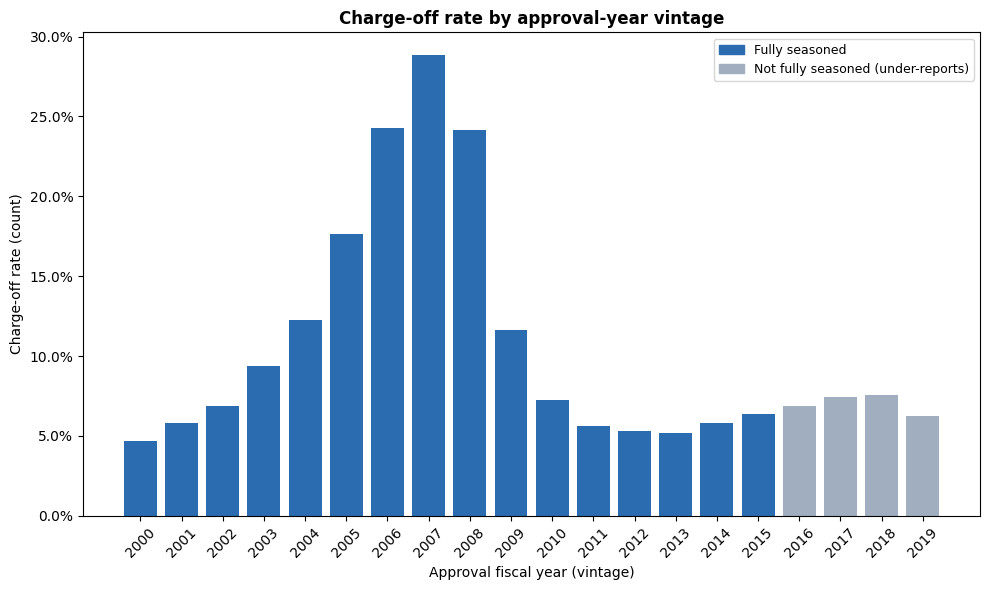

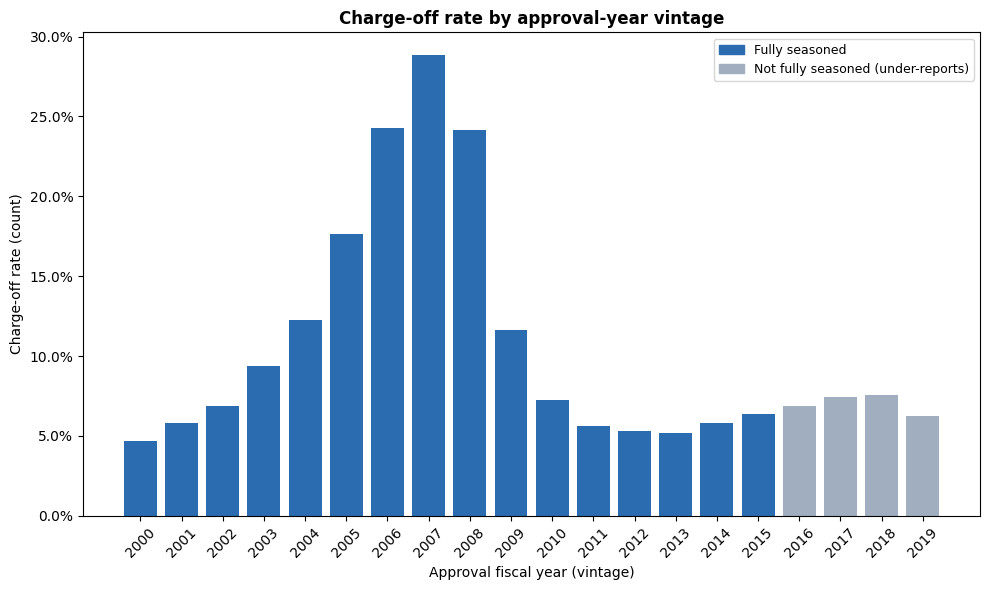

In [5]:
plot_chargeoff_by_vintage(co_vin)

#### Charge-off rate by loan-size band
Smaller loans default markedly more often.

In [6]:
co_size

,size_band,loan_count,defaults,exposure,chargeoff_amount,chargeoff_rate_count,chargeoff_rate_dollar
0,<=50k,458365,73713,1.254656e+10,2.417487e+09,0.1608,0.1927
1,50k-150k,260397,28699,2.700355e+10,3.076216e+09,0.1102,0.1139
2,150k-350k,163918,14908,4.121583e+10,3.516291e+09,0.0909,0.0853
3,350k-1m,137852,11241,8.310127e+10,5.866169e+09,0.0815,0.0706
4,1m-2m,49362,3599,7.056843e+10,4.044469e+09,0.0729,0.0573
5,>2m,17125,502,5.337338e+10,8.576691e+08,0.0293,0.0161


#### Vintage cohort curves — cumulative charge-off rate vs loan age

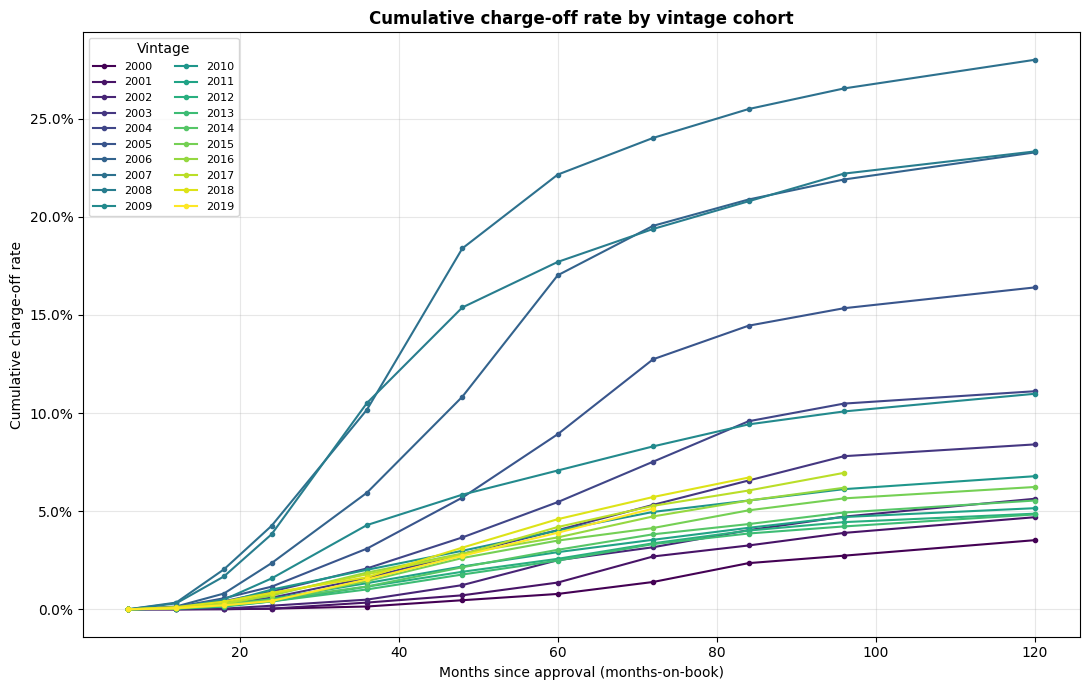

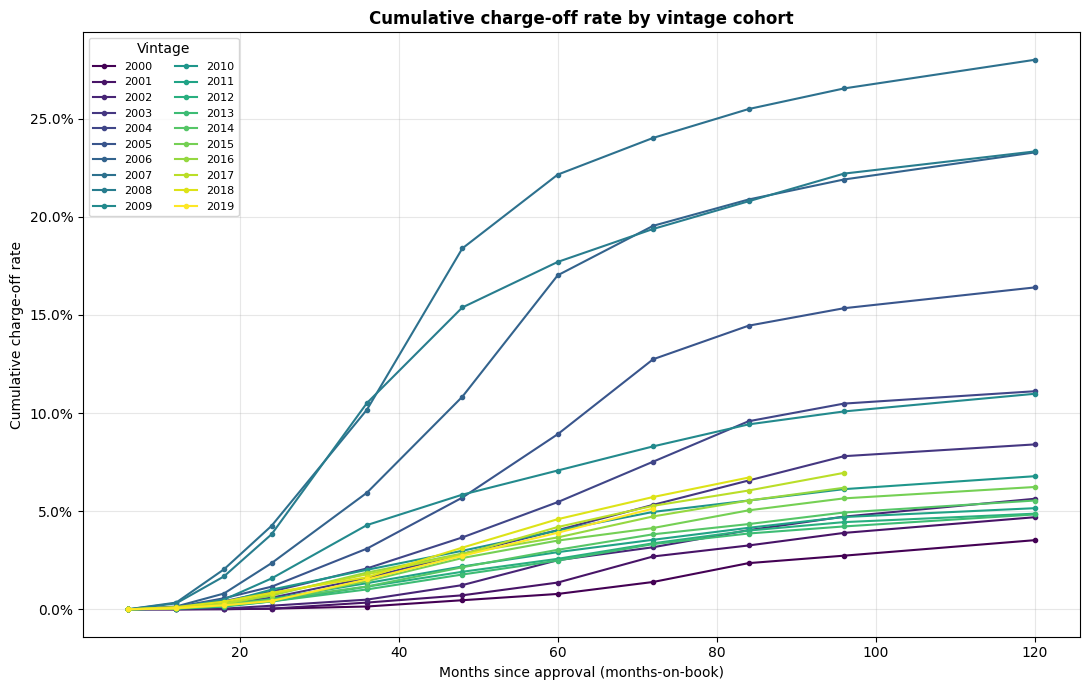

In [7]:
plot_vintage_curves(curves)

**Read-out:** the 2006–2008 vintages charged off at ~24–29% — roughly **5× the calm-year cohorts** — and their curves sit far above the rest. Smaller loans (≤\$50k) default ~16% vs ~3% for loans over \$2m.